# Machine Learning Algorithm Implementation

## Introduction

This notebook house the implementation of the machine learning models deployed using the preprocessed data from notebooks one and two. There will be two models deployed wihtin the notebook. The first, KMeans followed by DBSCAN. 

## 0.1 - Imports
The code block below represents where all imports for the noteboook are imported and initilised. 

In [1]:
# Import Library
import pandas as pd
import numpy as np
import seaborn as sns 

# Sklearn Imports:
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import davies_bouldin_score
from sklearn.neighbors import NearestNeighbors
from sklearn.manifold import TSNE

# Data Display Imports
import matplotlib.pyplot as plt

## 0.2 Import Datasets
This code block represents where all the datasets that will be worked on throughout this notebook are imported and initilised. 'customer_features' is copied in order to preserve the original data. 

In [2]:
# Import the scaled dataset
customer_features_scaled = pd.read_csv('../0_Data/processed_data/customer_features_scaled.csv')
customer_features = pd.read_csv('../0_Data/processed_data/customer_features.csv')

# Create a copy of the dataset we will be working on: 
scaled_df = customer_features_scaled.copy() 

FileNotFoundError: [Errno 2] No such file or directory: '../0_Data/processed_data/customer_features_scaled.csv'

## 1.0 Pre-Pipeline Steps
At this point scaling and preprocessing has been completely finished. However there are still a few steps we need to confirm before initlising the pipeline. The first is removing customer_id from the dataset. This is done because customer_id does not provide any benifit for the models in terms of unveiling consumer behaviour and secondly, it is the only column that did not have StandardScalar applied to it - as we did not want to change the actual customer_id's.

In [ ]:
# pull customer_id into its own dataset; 
customer_ids = scaled_df['customer_id']

# Drop customer_id from the working dataset: 
scaled_df = scaled_df.drop(columns=['customer_id'])

# Implement a function that checks if customer_id was successfully removed.
def customer_features_removal(df):
    if scaled_df.columns.all() == 'customer_id':
        print("'customer_id' still present")
    else: print("'customer_id' successfully removed")

# Call the customer_features_removal function using scaled_df. 
customer_features_removal(scaled_df)

'customer_id' successfully removed


## 2.0 - Machine Learning Pipeline Implementation
This chapter marks the begining of the machine learning model implementations. Starting with KMeans. 

### 2.1 - KMeans Algorithm
The first algorithm to be used is KMeans. KMeans is a common clustering algorithm and appropriate for a segmentation taks. This algoirthm splits data into a specified number of groups defined as 'k'. Each group has a centriod and points are assinged to specific groups depending on the distance each point is to a centriod. The reason for using this algorithm is to assess whether customers can be groups into distinc behavorial patterns/ types based on thier transactional profiles. The question KMeans aims to answer is can grouping customers in this manner reveal identifable differences; for example a group with high cancellation rates or high spend but low visits. 

### 2.2 - Determining K
KMeans is a clustering algorithim that is distance based. The idea behind its implementation within this context is to uncover clusters within the data. This is powerful as patterns that arent necessirily present then looking at raw data are uncovered during visual segments.

Before implementing the algorithm, the value of k needs to be determined. In this context K represents how many different groups or segments the algorithm will produce. It is important to find a suitable value for 'k' due to multiple reasons: 

- **If K is to low**: If the value of k is too low, unique and distinct bevahours can be missed where different groups are combined with eachother - removing the point of the algorithm entirely. For example, if k was too low, multiple different groups will be forced together in order to adhere to the algorithms demands. In this case the meaningful relationships we are trying to capture will be missed. 

- **k to high**: On the other hand if k is too high clusters fracture into indisgusiable segemnts that do not represent groupings of behaviour. An example of this is if k = 100 and was deployed on a dataset with 100 observations, there is a likely chance that each observations (or customer in this context) would be grouped on its own. This would not produce any meaningful insights. 

- **Getting k correct**: Getting k correct resembles the point where clusters represent meaningful and insightful behvioural patterns, which can be usd to uncover patterns within the data that would otherwise been missed. This is why finding the most suitable value of 'k' is important. 

**'k' Value Indentification Methodology:**
The first method that can be used to identify the most effective value of 'k' is the elbow method. This methods uses a metric known as 'inertia' as a way of measuring how closely plotted points are from their assinged cluster and is calulated by summing the square of the distances each point is from its centroid (cluster), this final summed value is what is known as the inertia. If inertia is low, it means that on average each points is situated closed to its own centriod meaning each point is tight within its own group and each point is behavorially similar to the other points in its group. If inertia is high, there is an indication that points are not tight but rather they are scattered far from their centroid. In this case groups are loose and contain multiple customers with different beahvioral traits that have been lumped together. This relates to choosing a value of 'k' as the more clusters that are requested, the smaller each group will be and naturally it means that each point will be closer to a more specific centroid. The key with this test is not identifying the lowest point but where the elbow is situated (displayed visually within a graph). The elbow represents the point at which increasing values of k stops providing value and start diluting clusters. Using the elbow method should result in a plot that decreases sharply at first and then levels off. It is at this point of the leveling off (the elbow) where the value of 'k' is the best choice for the data. 

Sometimes, the result of the elbow method does not produce a clear and distinct point of leveling off. This is why it is useful to deploy a second method of identifying the most suitable value of 'k' - silhouete score. 

Silhouette score is reponsible for measuring the quality of the clusters that are created. The silhouette score measures two things. The first is the how close each point is to the other points within its own cluster as well as how far away it is from points in other clusters. The idea is, if a point sits close to other points within its own cluster and far away from other clusters, it is given a high score (closer to +1). However, in the opposite case, if a point is sitting closer to another cluster, the score is lower (closer to -1). Scores are issued in the range of -1 to 1. By combining the average silhouette score for each point the result should indicate how well defined each cluster is - value of k with the highest silhouette score is usually the a solid indicator of the best value of 'k'.

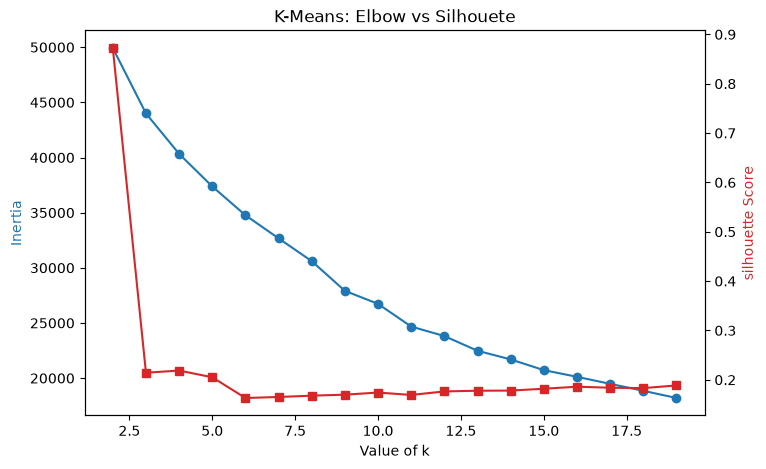

In [ ]:
# Initlise inertias and silhouette scroes lists as the metjod of storing results. 
inertias = []
silhouette_scores = []

# Initilise a range for k to be tested (2 through 20 inclusive)
k_range = range(2, 20)

# Initilise for each loop:
for k in k_range:
    # For each value of k re-initilise a KMeans algrithm wit the same parameters
    # random_state is a fixed value to ensure reproduceable results. 
    km = KMeans(n_clusters = k, random_state = 42, n_init = 10)
    # Fit the algorithm on the scaled dataset:
    labels = km.fit_predict(scaled_df)
    # Add the result km to inetias list.
    inertias.append(km.inertia_)
    # Use a seperate function using the original data and the labels data calculated above. 
    # This measures the degree of seperation between clusters - the result is appeneded to silhouete_scores list. 
    silhouette_scores.append(silhouette_score(scaled_df, labels))

# Initilise a plot to display the results from the inertias and silhouette_score lists. 
# Inetias Plot:
fig, ax1 = plt.subplots(figsize=(8, 5))
# Display the line with circles connected by a line: 
ax1.plot(k_range, inertias, 'o-', color = 'tab:blue', label = 'Inertia')
ax1.set_xlabel('Value of k')
ax1.set_ylabel('Inertia', color = 'tab:blue')

# Silhouette_score Plot:
ax2 = ax1.twinx()
# Display the line with squares connected by a line:
ax2.plot(k_range, silhouette_scores, 's-', color = 'tab:red', label = 'Silhouette')
ax2.set_ylabel('silhouette Score', color = 'tab:red')

# Title the plot:
plt.title('K-Means: Elbow vs Silhouete')

# Display the visulisation:
plt.show()

**Plot Results**

The plot above shows the results for both methods that were carried out. Inertia displays no slowing in the rate of decrease on inertia value, every iteration of 'k' improves inertia by roughly the same amount therefore giving no clear indication of a suitable value of 'k'.

Silhouette on the other hand, peaks at k = 2. A silhouette score of 0.9 for k = 2 indicates that there is a clear divide in the data that may be causing dilution within other features. A likely suspect for this is the wholesale customers that were kept during preprocessing. A low sihouette score, can be attributed to mutiple points that are pulled apart from others. Whilst these results are not necessirily wrong, theyre are unexpected and could indicate that some points may be influencing with both of these metrics.A likely cause of this is the wholesale transactions that were left in during preprocessing and should will be investigated for confirmation. 

To start building a picture of what is effecting the results, a describe() filtering to display only min and max values will be displayed below. This aims to provide an insight into range between the smallest and largest values in each feature. 

In [ ]:
# Display the Min and Max results of the scaled dataset:
scaled_df.describe().loc[['min', 'max']]

,total_spend,atv,total_visits,total_item_count,cancellation_rate,unique_products,time_of_day,day_of_week,discount_rate,loyalty_member
min,-2.036680,-48.946912,-0.410267,-0.326596,-0.676258,-0.690148,-2.483556,-1.369769,-1.426411,-0.647945
max,41.527424,22.346992,31.460162,42.868300,4.668382,21.270907,3.292813,1.853239,10.654583,1.543341


**Min & Max Descibe Evaluation**

As seen in the preprocessing pipeline, standardscalar was implemented on the data. When used standardscalar converts features and their values into standard deviations from the mean. This is helpful in ensuring every feature contributes equally in the case of features being on drastically different scales (for example total_spend being in the thousands and unique products being in the tens) as this would cause total_spend to dominate the distance calculations. Displaying the Min and Max values for each feature above confirms that there are values that sit drastically outside of the mean like total_spend having min and max values of -2.04 and 41.52 standard deviations from the mean and is evidence that extreme outliers can be distorting clusters. 

Whilst wholesale transactions represent a genuine business segment, their influence on other clusters is unhelpful. Before removing wholesale customers, it is necessary to identify a point at which treansactions stop behaving like typcial retail transactions and more like wholesale ones. To begin, a visual inspection on the sorted distribution of total_spend will be carried out. 


Distribution of total spend:


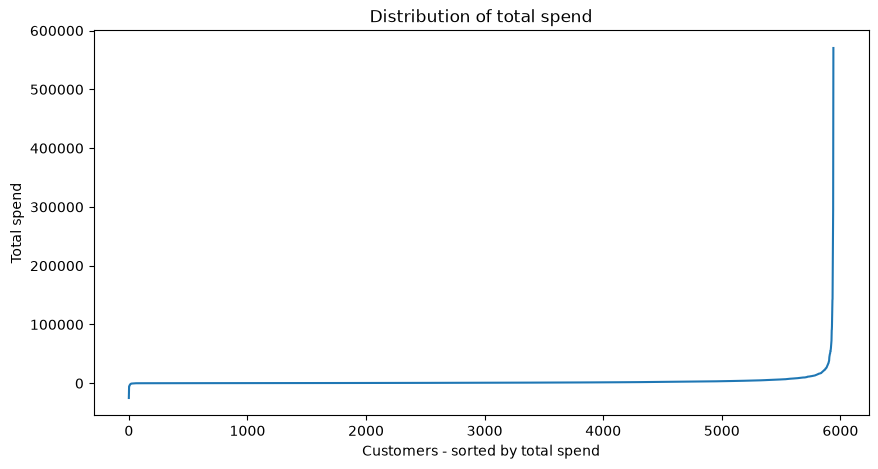

Tail Inspection of last 442 customers:


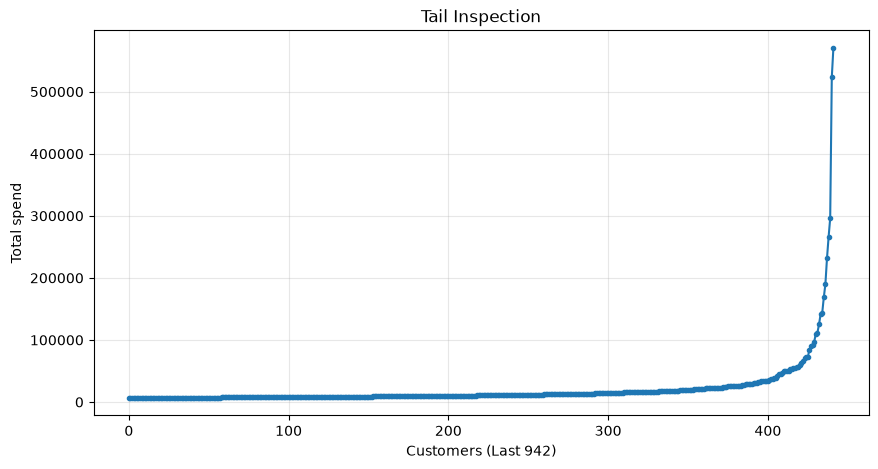

In [ ]:
# Create a variable using the unscaled customer_features - grouped on 'customer_id' and 'total_spend':
transaction_spend_split = customer_features.groupby('customer_id')['total_spend'].sum().sort_values()

# Initilise a plot to display the results:
# Set figure size:
plt.figure(figsize = (10, 5))
# Plot the values stored in the variable initilised above:
plt.plot(transaction_spend_split.values)
# X-label: Where each customer sits on an ordered total_spend list:
plt.xlabel('Customers - sorted by total spend')
# Y-label: Total Spend amount:
plt.ylabel('Total spend')
# PLot title:
plt.title('Distribution of total spend')
# Display the plot:
print("Distribution of total spend:")
plt.show()

# Initilise another variable focusing on the top 442 Customers:
tail_inspection = transaction_spend_split[5500 : 5942].reset_index(drop = True)

# Set figure size:
plt.figure(figsize = (10, 5))
#
plt.plot(tail_inspection.index, tail_inspection.values, marker = 'o', markersize = 3)
#
plt.xlabel('Customers (Last 942)')
#
plt.ylabel('Total spend')
# Set plot title
plt.title('Tail Inspection')
#
plt.grid(True, alpha = 0.3)
# Display the plot
print("Tail Inspection of last 442 customers:")
plt.show()



**Plot Evaluation**

The plot above is highly conclusive. As seen the vast majority of customers have a similar total spend of much less than £100,000 and there small amount of customers with extraordinary total_spend values. Inspecting the 'tail inspection' plot, the point at which total_spend begins to increase is the 400th customer mark. The extremes shown in both plots conclude that it is reasonable to remove any wholesale customers from the dataset. The plot indicates that total_spend starts increasing within the last  100-120 customers. To ensure the validity of the data 

Whilst the plot provides a useful visual indication, there is not enough information to establish a definative split between retail and wholesale consumers. Removing customers based on total spend alone may run the risk of removing valuable high spending retail customers (for example a loyal repeat customer with high spend and a high number of visits). 

To remove this risk, 'total_item_count' will also be used to try to identify wholesale transactions with more accuracy - it is rare that wholesale transacitons will have low spend and quantity amounts, as such is the nature of wholesale transacitions, as bulk purchases are intrinsic within their nature. 

To formalise this definition, a threshold is defined using the 95th percentiles combined on total_spend and total_item_count. This means that a customer will only be classified as a wholesale customer if they exceed both percentile thresholds. 

In [ ]:
# Initilise a variable representing the 95th percentile value for spend and qty
# Total Spend
spend_cutoff = customer_features['total_spend'].quantile(0.95)
# Total Item Count
quantity_cutoff = customer_features['total_item_count'].quantile(0.95)

# Establish a boolean mask marking a customer as True for 95th percentile values. 
wholesale_marker = ((customer_features['total_spend'] >= spend_cutoff) & 
                    (customer_features['total_item_count'] >= quantity_cutoff))

# Remove all instances of customers who are above the threshold: 
# Store the observations 
retail_features = customer_features[~wholesale_marker]

# Print values: 
print("")
print(f"Total Spend Cutoff Value: £{spend_cutoff:.2f}")
print(f"Quantity Cutoff Value: {quantity_cutoff:.2f}")
print(f"Total Customer Profiles Removed: {5942 - len(retail_features)}")
print(f"Remaining Retail Cusotmers: {len(retail_features)}")



Total Spend Cutoff Value: £8746.50
Quantity Cutoff Value: 5180.85
Total Customer Profiles Removed: 234
Remaining Retail Cusotmers: 5708


In [ ]:
# Re-initilise Feature_cols variable, without customer_id: 
feature_cols = ['total_spend', 'atv', 'total_visits', 'total_item_count',
                'cancellation_rate', 'unique_products', 'time_of_day', 'day_of_week',
                'discount_rate', 'loyalty_member']

# Re-initilise StandardScaler:
scaler = StandardScaler()

# Re-run StandardScalar on the retail dataset: 
retail_scaled = scaler.fit_transform(retail_features[feature_cols])

Now that wholesale customers will have been removed from the dataset and StandardScalar has been re-deployed. A Min and Max describe will be ran again comparing the results with the original test and to confirm if outlier results were removed successfully. 

In [ ]:
# Display the Min and Max results of the scaled dataset:
pd.DataFrame(retail_scaled, columns= feature_cols).describe().loc[['min', 'max']]

,total_spend,atv,total_visits,total_item_count,cancellation_rate,unique_products,time_of_day,day_of_week,discount_rate,loyalty_member
min,-13.394317,-56.511128,-0.691893,-1.641791,-0.657119,-0.824025,-2.479732,-1.369313,-1.398501,-0.646090
max,7.422657,10.269374,13.995024,12.561533,4.630330,9.651345,3.270637,1.838803,10.456100,1.547772


When comparing with original min and max describe output, we can see that the high-end maximums have drastically improved (total_spend dropped from a max of 41.5 to 7.4 and total_item_count is down from 31.5 to 14.0). This is clear evidence that removing the wholesale transacitons has improved the spread of values. 

It is worth noting however, that ATV min and max values worsened specifically in the negative direction:

- Min: -48.94 -> -56.51
- Max: 22.34 -> 10.2

Before investigating, elbow and silhouette tests will be ran again, assessing the differences and determining whether extreme values are still affecting the data. 

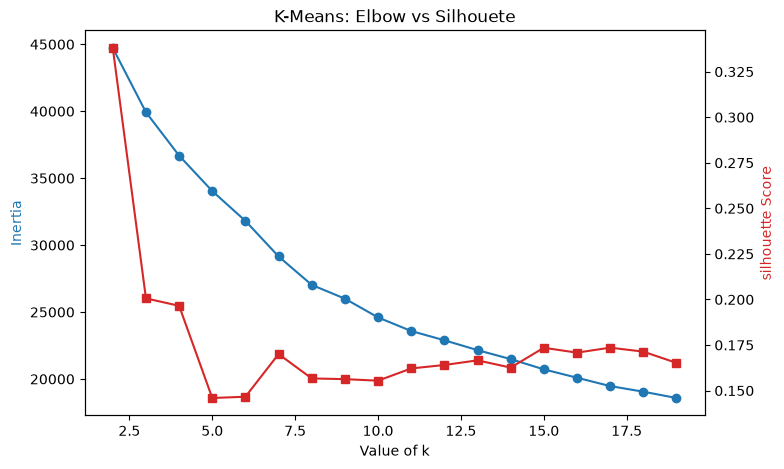

,k,inertia,silhouette
0,2,44723.208260,0.337985
1,3,39925.921678,0.200610
2,4,36684.290386,0.196526
3,5,34038.815967,0.145943
4,6,31808.353917,0.146631
5,7,29154.276817,0.170045
6,8,27027.837373,0.156680
7,9,26001.141865,0.156290
8,10,24598.489368,0.155442
9,11,23583.308883,0.162159


In [ ]:
# Initlise inertias and silhouette scroes lists as the metjod of storing results. 
inertias = []
silhouette_scores = []

# Initilise a range for k to be tested (2 through 20 inclusive)
k_range = range(2, 20)

# Initilise for each loop:
for k in k_range:
    # For each value of k re-initilise a KMeans algrithm wit the same parameters
    km = KMeans(n_clusters = k, random_state = 42, n_init = 10)
    # Fit the algorithm on the scaled retail data:
    labels = km.fit_predict(retail_scaled)
    # Add the result km to inetias list.
    inertias.append(km.inertia_)
    # Use a seperate function using the original data and the labels data calculated above. 
    # This measures the degree of seperation between clusters - the result is appeneded to silhouete_scores list. 
    silhouette_scores.append(silhouette_score(retail_scaled, labels))

# Implement a dataframe showing results as numerical values:
results_df = pd.DataFrame({
    'k' : list(k_range),
    'inertia' : inertias,
    'silhouette' : silhouette_scores
}
)

# Initilise a plot to display the results from the inertias and silhouette_score lists. 
# Inetias Plot:
fig, ax1 = plt.subplots(figsize=(8, 5))
# Display the line with circles connected by a line: 
ax1.plot(k_range, inertias, 'o-', color = 'tab:blue', label = 'Inertia')
ax1.set_xlabel('Value of k')
ax1.set_ylabel('Inertia', color = 'tab:blue')

# Silhouete_score Plot:
ax2 = ax1.twinx()
# Display the line with squares connected by a line:
ax2.plot(k_range, silhouette_scores, 's-', color = 'tab:red', label = 'Silhouette')
ax2.set_ylabel('silhouette Score', color = 'tab:red')

# Title the plot:
plt.title('K-Means: Elbow vs Silhouete')

# Display the visulisation:
plt.show()

results_df

Visual inspection does condifrm that results were better than the original tests. There is now some indication that k = 7 displays improving results for silhouette scores as well as k = 4. However there is still a peak at k = 2. This indicates that the wholesale removal step was suitable for removing high end extremes but may have missed other types of extreme values. 

As mentioned in the previous min and max describe results, atv displayed values that were -56 devisations from the mean. To investigate this, the five smallest observations on total_spend acorss five features will be inspected. 

In [ ]:
# Print a list of smallest (5) customers on total_spend
customer_features.nsmallest(5, 'total_spend')[['customer_id', 'total_spend', 'atv', 'total_visits', 'total_item_count']]

,customer_id,total_spend,atv,total_visits,total_item_count
5053,17399,-25111.09,-25111.090000,1,-1
572,12918,-10953.50,-3651.166667,3,-1
3503,15849,-5876.34,-5876.340000,1,-1
3414,15760,-5795.87,-1159.174000,5,-1
4635,16981,-4620.86,-4620.860000,1,-1


The results above show that there are outliers still present even after the wholesale removal stage. These values were not caught in that step due to having negative values on total_spend, atv and total_item_count and the wholesale filter only targeted customers with high postive spend and quantity, not low or negative values.

The pattern observed across the observations is that total_item_count values are all negative. This negative value does not reflect a genuine purchasing behaviour and is likely caused by cancellation or return transactions that arent accompanyed by the original purchasing record. 

To make a decision about what sort of action should be taken for this issue, the next step is to quantify how many customers have a negative total_item_count. This will help determine whether or not it is appropriate to remove these observations or not.

In [ ]:
# Sum the number of instances where total_item_count is less than 0:
(customer_features['total_item_count'] <= 0).sum()

np.int64(99)

with only 99 observations of total_item_count being less than 0 (or about 1.7%) this is small enough to remove all instances comeplelty and re-test the elbow and silhoutte tests. 

There is reportedly only 99 observations out of over 5000 where total_item_count is less than 0. This means these observations account for a only 1.7% of the total observations within the data set, meaning it is more than reasonable to remove them and then re-test the elbow and silhouette tests in order to assess any changes that have occured. 

In [ ]:
# Remove all instances of total_item_count being less than 0
retail_features = retail_features[retail_features['total_item_count'] > 0]

# Re-fit Standard Scalar: 
retail_scaled = scaler.fit_transform(retail_features[feature_cols])

In [ ]:
pd.DataFrame(retail_scaled, columns=feature_cols).describe().loc[['min','max']]

,total_spend,atv,total_visits,total_item_count,cancellation_rate,unique_products,time_of_day,day_of_week,discount_rate,loyalty_member
min,-2.730279,-2.526191,-0.698020,-0.749599,-0.685944,-0.835143,-2.480628,-1.371033,-1.536803,-0.645302
max,7.574907,18.116087,13.908216,12.503098,4.221882,9.607108,3.295517,1.827189,11.518829,1.549663


The record above shows a positive change for both total_spend and atv. Atv's minimum was reduced from -56.5 -> -2.5 and total_spends minimum was reduced from -13.4 -> -2.7 - both now sit in much more normal and expected ranges. This change is confirmation that the removed invalid records were in fact causing some distortion. All other columns stayed roughly the same, which is expected as removing only 99 columns wont shift the other features as much.

Now the data has been inspected, intertia and silhouette will be re-tested. In addition, a third metric will be added - Davies-Bouldin Index. This will be done in order to aid the identification of 'k'. The choice to use Davies-Bouldin is due to its ability to measure cluster quality as it measures how compact each cluster is against how far the same cluster sits from neighbouring clusters. Using a 3rd metric calculated via a different measurement than the other two metrics provides a stronger evidence of a suitable value of 'k'. 

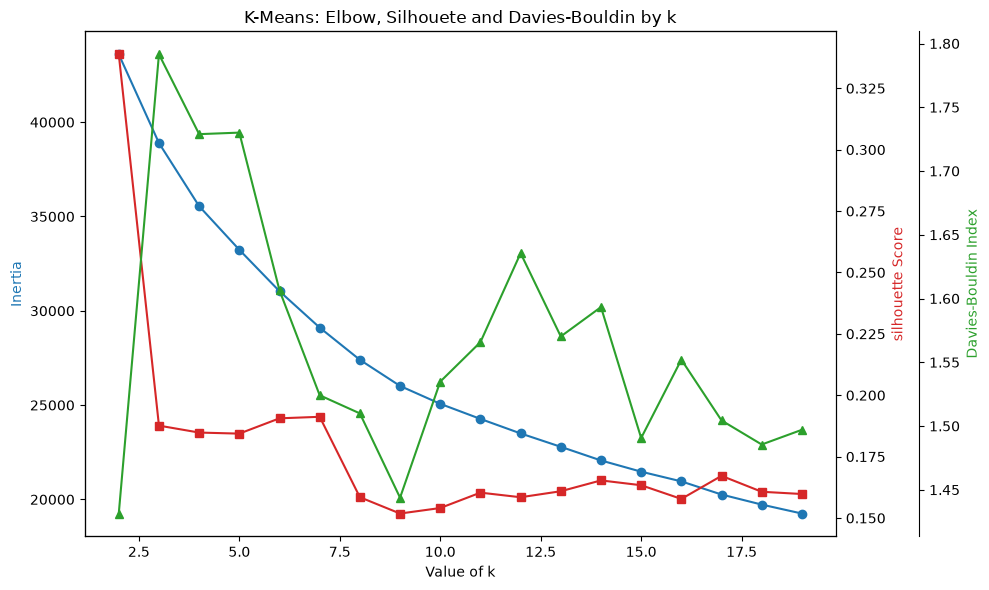

,k,inertia,silhouette,davies_bouldin
0,2,43600.438842,0.338837,1.431359
1,3,38896.420388,0.187630,1.791541
2,4,35546.451112,0.184802,1.728913
3,5,33235.601987,0.184372,1.730113
4,6,31036.404605,0.190600,1.606372
5,7,29108.451675,0.191219,1.524119
6,8,27401.245965,0.158476,1.509894
7,9,26015.405522,0.151830,1.443769
8,10,25067.607448,0.154075,1.534803
9,11,24267.206854,0.160339,1.565778


In [ ]:
# Initlise inertias and silhouette scroes lists as the metjod of storing results. 
inertias = []
silhouette_scores = []
db_scores = []

# Initilise a range for k to be tested (2 through 20)
k_range = range(2, 20)

# Initilise for each loop:
for k in k_range:
    # For each value of k re-initilise a KMeans algrithm wit the same parameters
    km = KMeans(n_clusters = k, random_state = 42, n_init = 10)
    labels = km.fit_predict(retail_scaled)
    # Add the result km to inetias list.
    inertias.append(km.inertia_)
    # Use a seperate function using the original data and the labels data calculated above. 
    # This measures the degree of seperation between clusters - the result is appeneded to silhouete_scores list. 
    silhouette_scores.append(silhouette_score(retail_scaled, labels))
    # Record the scores for the Davies-Bouldin test into the db list: 
    db_scores.append(davies_bouldin_score(retail_scaled, labels))

# Implement a dataframe showing results as numerical values:
results_df = pd.DataFrame({
    'k' : list(k_range),
    'inertia' : inertias,
    'silhouette' : silhouette_scores, 
    'davies_bouldin' : db_scores
}
)

# Initilise a plot to display the results from the inertias and silhouette_score lists. 
# Inetias Plot:
fig, ax1 = plt.subplots(figsize=(10, 6))
# Display the line with circles connected by a line: 
ax1.plot(k_range, inertias, 'o-', color = 'tab:blue', label = 'Inertia')
ax1.set_xlabel('Value of k')
ax1.set_ylabel('Inertia', color = 'tab:blue')

# Silhouete_score Plot:
ax2 = ax1.twinx()
# Display the line with squares connected by a line:
ax2.plot(k_range, silhouette_scores, 's-', color = 'tab:red', label = 'Silhouette')
ax2.set_ylabel('silhouette Score', color = 'tab:red')

# Davies-Bouldin Plot
ax3 = ax1.twinx()
# Display the axis line to the right to ensure visability.
ax3.spines['right'].set_position(('outward', 60))
ax3.plot(k_range, db_scores, '^-', color = 'tab:green', label = 'Davies-Bouldin')
ax3.set_ylabel('Davies-Bouldin Index', color = 'tab:green')

# Title the plot:
plt.title('K-Means: Elbow, Silhouete and Davies-Bouldin by k')
fig.tight_layout()
# Display the visulisation:
plt.show()

results_df

**Analysis**

Removing the negative 'total_item_count' values only led to minimal positive changes within the results for both silhouette and the elbow method. Silhouette scores still sits firmly at k = 2 sugesting this split is a reflection of genuiene customer behaviour rather than distortion caused by extreme outlying values. When comparing with the previous tests, there is some improvement in the mid ranges for k. For example k = 7 sees a modest rise from 0.170 -> 0.191 sugesting that the invalid negative values were causing some noise within the clusters. After this point however, results remain virtually unchanged. Past k = 8 both tests reflect low flat scores in the ranges 0.15 - 0.17. Inertia also displays no meaningful changes either. Both tests visually show a smooth curved line with no clear elbow point. The thrid metric; Davies-Boulin reinforces the silhouette result as it too also reaches its lowest (best) value at k = 2. Both metrics converging on the same value of k whilst using different methods of calculation provides strong evidence that k = 2 does reflect a genuiene segmentation split. There is a close second result for this metric at k = 9 (1.44) however with this value of k also being attributed to having the lowest silhouette score, it will not be tested further. After this point, the Davies-Boulin results display no clear secondary suggestion; including k = 7; which supports ealier deductions that there is no other value of k that comes close to k = 2 on the basis of statistics alone. 

Whilst k = 2 is statistically the strongest result, a k value of 7 will also be inspected as it is the second highest silhouette result - under the logic that more clusters may reveal more business-actionable level insights. On the other hand, inertia provided no meaningful indication of a suitable k value as neither tests displayed an identifable elbow.  

### 2.3 - Running Kmeans Algorithm Tests
This section showcases the tests and results for both values of k (2, 7) starting with k = 2.

In [ ]:
# Initilise a K-means model using 2 clusters (dominant split test)
Kmeans_two = KMeans(n_clusters=2, random_state=42, n_init=10)
# Fit the model to the scaled retail data - assinging customers a value (0,1)
labels2 = Kmeans_two.fit_predict(retail_scaled)

# Add the cluster labels into the dataset corresponding each customer with their value: 
retail_features['cluster_k2'] = labels2
print("=== KMEANS ALGORITHM RESULTS (K = 2) ===")
# Groupby averages the customers within each cluster value for each feature and returns the mean. 
retail_features.groupby('cluster_k2')[feature_cols].mean()

=== KMEANS ALGORITHM RESULTS (K = 2) ===


,total_spend,atv,total_visits,total_item_count,cancellation_rate,unique_products,time_of_day,day_of_week,discount_rate,loyalty_member
cluster_k2,,,,,,,,,,
0,822.633877,255.075132,3.609856,485.409081,0.097953,47.479664,12.592425,2.564235,0.117639,0.288358
1,4953.323155,395.061605,16.535343,2937.314969,0.178758,195.692308,12.537422,2.610187,0.118063,0.321206


**k = 2 Cluster Results**

The results from the KMeans test above displays clear split that is consitant with the silhouette score results. Cluster 1 shows much higher values across features in comparison to cluster 0. For example: 

- total_spend = ~ 6 times higher in cluster 1 (£4,953 -> £823)
- visit_frequency = ~ 4 times higher in cluster 1 (16.5 vs 3.6)
- total_item_count = ~ 6 times higher in cluster 1 (2937 vs 485)
- unique_products = ~ 4 times higher in cluster 1 (195 vs 47)

Other features such as 'discount_rate' and 'loyalty_member' displayed minimal difference between the two segements. This is an indication that these features are not meaningfully contributing the the split. 

These results show that when k = 2 the split is being entirely by engagement based metrics alone (like spend, frequency, product variety) and other metrics suchs as discounts and loyalty contribute little to clusters. More specifically, in this example the split is represented by low-engagment occasional custoewrs (cluster 0) followed by high-engagement, frequently visiting customers (cluster 1). 

The next test will be deploying a Kmeans algorithm with a k value of 7. 

In [ ]:
# Initilise a K-means model using 7 clusters (second highest silhouette score)
Kmeans_seven = KMeans(n_clusters=7, random_state = 42, n_init=10)
# Fit the model to the scaled retail data - assinging customers a value (0,1)
labels7 = Kmeans_seven.fit_predict(retail_scaled)
# Add the cluster labels into the dataset corresponding each customer with their value: 
retail_features['cluster_k7'] = labels7
print("=== KMEANS ALGORITHM RESULTS (K = 7) ===")
# Groupby averages the customers within each cluster value for each feature and returns the mean. 
retail_features.groupby('cluster_k7')[feature_cols].mean()

=== KMEANS ALGORITHM RESULTS (K = 7) ===


,total_spend,atv,total_visits,total_item_count,cancellation_rate,unique_products,time_of_day,day_of_week,discount_rate,loyalty_member
cluster_k7,,,,,,,,,,
0,3262.779901,317.950860,11.693456,1959.339839,0.155368,156.594719,12.518944,2.832377,0.118148,0.250287
1,610.088406,243.966556,2.660603,362.404500,0.009726,39.710866,12.680230,2.619435,0.098856,0.000000
2,323.481187,196.026409,1.812785,170.392694,0.012545,11.767123,12.360731,2.337900,0.344463,0.191781
3,7140.827938,347.119684,24.395062,4255.537037,0.186014,261.058642,12.487654,2.469136,0.119850,0.327160
4,827.194655,266.084414,3.387534,487.216802,0.051746,48.321590,12.767841,2.592593,0.110695,1.000000
5,3146.036280,1485.126692,2.224299,1643.345794,0.037461,69.644860,12.476636,2.242991,0.112209,0.364486
6,935.784228,190.517381,5.213004,545.345291,0.389243,46.457399,12.290359,2.316143,0.114366,0.153587


**k = 7 Cluster Results**
Increasing the value of k from 2 to 7 reveals richer and more descriptive consumer segments. Rather than a split based on engagment metrics seen in k = 2, this split provies seven distinct and interpretable customer segments. There are various different characteristics seen with the results above, for example: 

- **Cluster 0:** With the second highest total_spend and total_visit values, this cluster could represent regular, engaged customers. 

- **Cluster 1:** Low spend and low values for the rest of the features. Most notably loyalty has a value of 0, indicating this cluster represents non-loyalty members. 

- **Cluster 2:** The lowest spend value paired with the fewest unique products but the highest discount rate value, this cluster represents small discount driven purchases. 

- **Cluster 3:** highest spend followed by most visits and most items bought as well as most amount of unique products. This cluster represents the business' core customers. 

- **Cluster 4:** Cluster 4 has a modest spend value, being only the 3rd lowest however, the key with this cluster is loyalty having a value of 1. This cluster reflects the behaviours of membership customers.

- **Cluster 5:** This cluster has a specific behaviour. With a moderate mid value spend paired with the highest average transaction and a low visit value. This cluster points to a group of high value infreuqent one-off purchases. 

- **Cluster 6:** Mid range spend, lowest average transaction value and highest cancellation rate, this cluster indicates a group of frequent low value repeat customers. 

Increasing the value of K within this algorithm clearly returns a much more profficient result in comparison to the k = 2 split. Here we can see multiple different cluster behaviours from core customers to infrequent large transactions to customers who prefer to shop with discounts. 

An interesting point to investigate is the effect the binary feature 'loyalty_member'. With this feature only containing binary values (either the customer is a member or they are not) there may be an effect on the results. In some cases this split of values between 0 and 1 can act as a immediate split rather than a gradual one. This is relevant in this case specifically on clusters 1 and 4 where there is an exact split on loyalty member, despite both clusters showing similar values wihtin the rest of the other features. This may indicate that in this case 'loyalty_member' is disproportionately contributing to the outcome. To investigate this, another Kmeans algorithm will be implemented without 'loyalty_member' and with a k value of 7 and the results will be assessed. 

In [ ]:
# Remove the featureok that  from the dataset: 
binary_removal_features = retail_features.drop(columns=['loyalty_member'])

# Create a new list without loyalty_member
removed_feature_cols = [col for col in feature_cols if col not in ['loyalty_member']]

# Refit Standard Scalar: 
binary_removed_scaled = scaler.fit_transform(binary_removal_features[removed_feature_cols])

# Run K means again using new dataframe:
Kmeans_seven_tuned = KMeans(n_clusters=7, random_state = 42, n_init=10)
labels2 = Kmeans_seven_tuned.fit_predict(binary_removed_scaled)
retail_features['cluster_no_loyalty'] = labels2
retail_features.groupby('cluster_no_loyalty')[removed_feature_cols].mean()

,total_spend,atv,total_visits,total_item_count,cancellation_rate,unique_products,time_of_day,day_of_week,discount_rate
cluster_no_loyalty,,,,,,,,,
0,349.877331,204.455241,1.832669,190.944223,0.011942,12.641434,12.573705,2.183267,0.330174
1,3245.662306,329.161444,11.466523,1942.800216,0.150320,153.628510,12.546436,2.724622,0.118321
2,7162.219259,348.517354,24.392523,4272.473520,0.185236,261.993769,12.501558,2.482866,0.119917
3,944.169430,191.763904,5.235234,555.832994,0.381494,47.024440,12.321792,2.285132,0.114185
4,649.917915,246.867834,2.835406,379.085589,0.019632,46.666423,13.883687,4.283102,0.104155
5,666.226356,265.331288,2.722813,393.241135,0.012472,38.135343,11.720449,1.363475,0.098788
6,3609.063600,1752.379254,2.142857,1908.100000,0.041905,69.500000,12.585714,2.185714,0.109362


Removing 'loyalty_member' from the algorithm produced insightful results. Firstly, 5 out of 7 clusters remained virtually unchanged. The top-tier core customers, high ATV low-frequency customers, regular engaged consumers, high cancellation repeat customers and discount driven groups all remain in both results (under a different cluster index). This indicates that these clusters are repeatable and display that there is infact specfic behaviours associated with each one. 

Secondly, the other two featues; previsouly containing the loyalty_member split did produce different results onces the feature was removed. Clusters 4 and 5 reflect these changes. Whilst certain featueres like 'total_spend', 'atv' and 'total_item_count' are similar in value are not distinguished by 'day_of_week'. At 4.2 -> 1.3 there is a clear gap between these two clusters unlike any other group within this feature. This represents a genuiene characteristic that was originally hiden by the binary feature's influence. 

In conclusion, removing loyalty_member proved that the binary feature was artificially contributing to these two specific clusters, while the remaining 5 were left un-affected. 

### Scatter Plot
WHy have I implemented a scatter plot? below are the results for k =2 and k = 7 

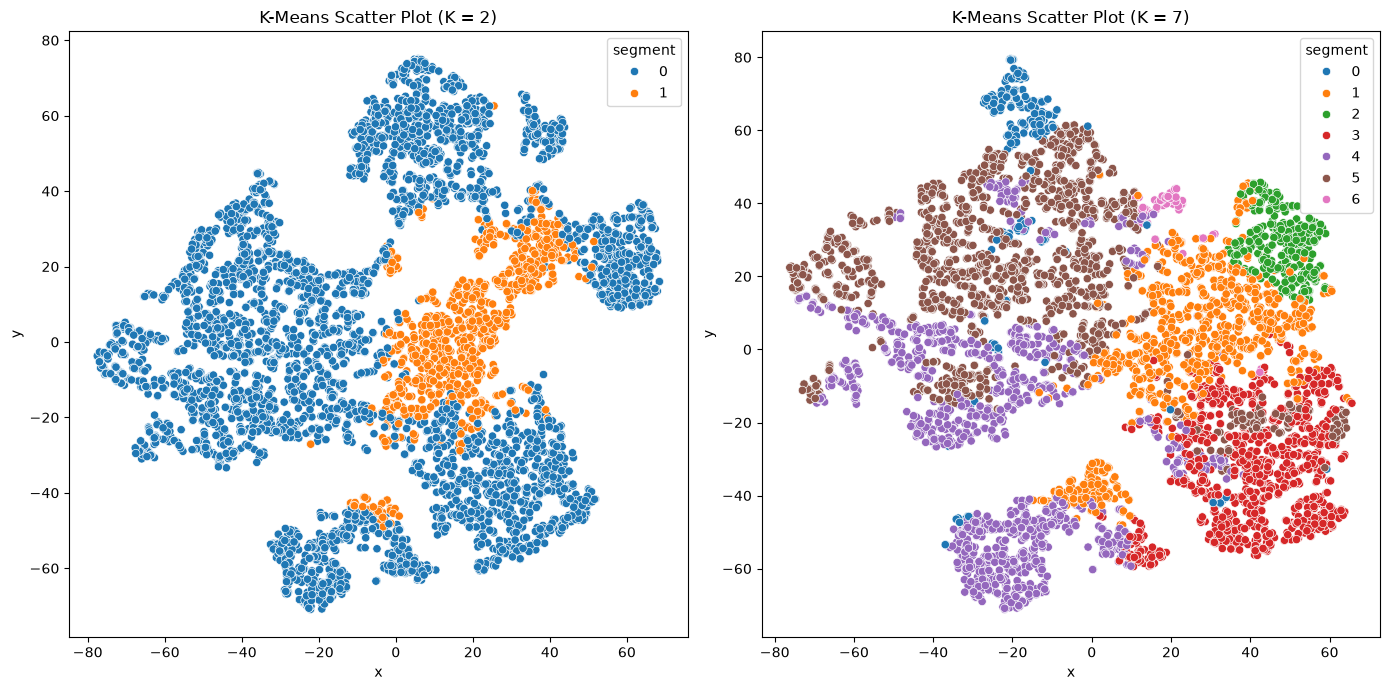

In [ ]:
# K = 2 Scatter plot:
# Initilise Scatter Plot Tool and compress down to two dimensions:
tsne_k2 = TSNE(n_components = 2, random_state = 42)
# Fit the plot to retail scaled
tsne_data_k2 = tsne_k2.fit_transform(retail_scaled)

# K = 7 Scatter Plot:
# Initilise Scatter Plot Tool and compress down to two dimensions:
tsne_k7 = TSNE(n_components = 2, random_state = 42)
# Fit the plot to the scaled data not containing 'loyalty_member':
tsne_data_k7 = tsne_k7.fit_transform(binary_removed_scaled)

# Initilise Dataframe of the dimentions plus the customer cluster labels for k = 2:
df_tsne_k2 = pd.DataFrame({'x': tsne_data_k2[:, 0], 'y': tsne_data_k2[:, 1],
                        'segment': retail_features['cluster_k2']})

# Initilise Dataframe of the dimentions plus the customer cluster labels for k = 7:
df_tsne_k7 = pd.DataFrame({'x': tsne_data_k7[:, 0], 'y': tsne_data_k7[:, 1],
                        'segment': retail_features['cluster_no_loyalty']})

# Initilise the plot - each customer represents a dot
# dots are coloured to represent the cluster they belong to:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))


# Initilise the plots: 
sns.scatterplot(x = 'x', y = 'y', hue = 'segment', data = df_tsne_k2, palette = 'tab10', ax = axes[0])
axes[0].set_title('K-Means Scatter Plot (K = 2)')
sns.scatterplot(x = 'x', y = 'y', hue = 'segment', data = df_tsne_k7, palette = 'tab10', ax = axes[1])
axes[1].set_title('K-Means Scatter Plot (K = 7)')

# Display the plots:
plt.tight_layout()
plt.show()

### Scatter Plot Results

**k = 2 Plot**
The first plot (k = 2) displays a much clearer structure in comparison with the plot next to it. While there is some overlap between the clusters towards the centre of the plot, there is still a visible division between them. For example cluster 1 (orange) is concenrated towards the right hand side and cluster 0 (blue) is more concentrated within the lower left sections of the plot. These visual results alighn with the statistical results that generated during the silhouette tests - as k = 2 produced the strongest silhouette score at 0.339 as well as the strongest Davies-Bouldin score - 1.431. The visulisation further supports the conclusion that the behaviour observed within this data occurs along a continous spectrum as opposed to a definitive split.

**k = 7 Plot**
There are mixed results found within the plot. Firstly, some clusters, like cluster 2 (green), cluster 0 (blue) and pink (cluster 6) show some collective strucutre. However the other clusters; specifically brown (cluster 5) and purple (cluster 4) lack a tight structure and overlap heavily. 

Reflecting on these results, the visulisation is consistant with the results produced previously. For example this split uses a k value of 7. This value only received a modest (0.15 - 0.19) silhouette score which is not a particularly high score and this plot correspends with those results. Rather the visulation does an excellent job at honestly reflecting the natural behaviour of the data which is that the observed customer behaviour is a continous spectrum as opposed to distinct seperate segments. The K-means results produce several behaviourally different profiles; confirmed within the tables; but the visulisation adds that the context between the neighbouring clusters is not sheer but rather gradual.  

## 3.0 - DBSCAN

DBSCAN standing for **D**ensity-**B**ased **S**patial **C**lustering of **A**pplications and **N**oise is another clustering algorithm. The difference is this algorithm identifies groups using a measurement of density rather than distance. The algorithm does not work with a predetermined value of groups (like 'k') rather it identifies groups where points are closely packed together and labels them as a cluster. Any points that are found "groupless" are labelled as noise. 

**DBSCAN's Hyperparameters:**

- **EPS**: This represents the maximum distance between two points in order for them to be classified as neighbours. If eps is too small then points are isolated and labelled as noise. On the contrary, if eps is too large all points are collapsed together into one single cluster.

- **min_samples**: This hyperparameter represents the sizing of each cluster. More specifically it represents the minimum number of points that are in proximity to each other in order for that area to be classified as dense - in this case labelled as a cluster. 

Similarly to Kmeans, before running the algortihm as suitable value for eps must be determined. Rather than selecting a value randomly a k-distance plot will be used. This follows the same logic as the elbow method for the KMeans algorithm. For each point in the dataset, the distance to its nth neighbour is calculated. Points in desnse locations will have smaller distances, resulting in a low score whereas points in more spread out sections will have larger distances and therefore a higher score. Visually we are looking for the 'knee' which follows the same logic as the 'elbow' that was to be identified in the elbow method. The knee represents a mid-point for points that are too spread apart and points that are packed together. 

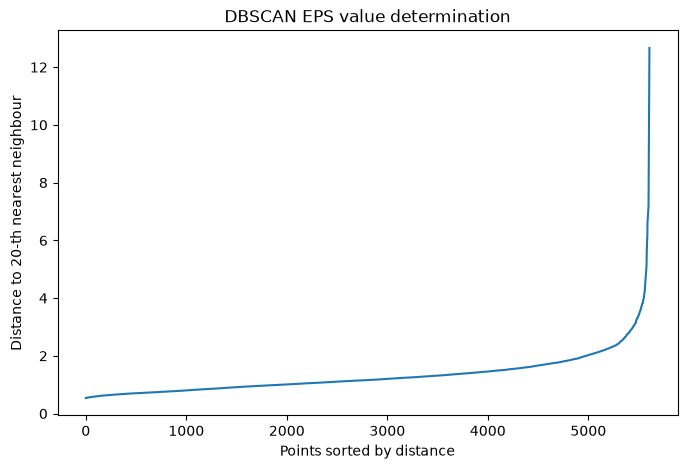

In [ ]:
# Set min_samples to rule of thumb = twice the number of features. 
min_samples = 2 * len(feature_cols)

# For every point - find its min_samples nearest neighbours.
neighbors = NearestNeighbors(n_neighbors = min_samples)
neighbors_fit = neighbors.fit(retail_scaled)
distances, indicies = neighbors_fit.kneighbors(retail_scaled)

# Get each points distance to its furthest neighbour, in ascending order:
k_distances = np.sort(distances[:, -1])

# Plot the sorted distances:
plt.figure(figsize=(8, 5))
plt.plot(k_distances)
# Labels:
plt.xlabel('Points sorted by distance')
plt.ylabel(f'Distance to {min_samples}-th nearest neighbour')
# Plot title: 
plt.title('DBSCAN EPS value determination')
# Display the plot: 
plt.show()

### Plot Analysis

The plot show that most points sit close together, which is confirmed by the flat section of the curve. However points that are further away from their neighbours naturally cause the distance to increase which is characterised by the sharp curve. The part of the plot where the curve initily starts to climb is the 'knee' - the value we are looking for. Here the knee occurs in the region of 2 - 4. To build a better understanding of where the knee actually sits, a closer inspection of the furthest values will be carried out. 

In [ ]:
# Inspect the values for distances in the region of the 'knee'
for position in [4000, 4500, 5000, 5200, 5400,5500, 5600, 5607]:
    print(f"Distanece Value: {position} -> {k_distances[position]:.4f}")

Distanece Value: 4000 -> 1.4564
Distanece Value: 4500 -> 1.6616
Distanece Value: 5000 -> 2.0205
Distanece Value: 5200 -> 2.2527
Distanece Value: 5400 -> 2.7903
Distanece Value: 5500 -> 3.4023
Distanece Value: 5600 -> 7.7853
Distanece Value: 5607 -> 12.3626


From the results above the curve occurs between the distance values of 5500 and 5600 with values of 3.4 and 7.79 respectively. Given that 5500 represents the start of the curve, we will label this the knee and select a value of 3.4 for EPS to test.

In [ ]:
# Set the EPS value: 
eps_value = 3.4 
# min_samples has already been initilised. 

# Initilise DBSCAN: 
db = DBSCAN(eps = eps_value, min_samples = min_samples)

# Fit the model with the data: 
db_labels = db.fit_predict(retail_scaled)

# Init variable to count clusters: 
n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
# Init variable to count noise: 
n_noise = list(db_labels).count(-1)

# Print results: 
print(f"Clusters Found: {n_clusters}")
print(f"Noise Points: {n_noise}")

Clusters Found: 1
Noise Points: 41


Despite the analysis above the results here show that an eps value of 3.4 is not suitable. Using this value resulted in 41 noise points and only one cluster meaning the vast majority of points were lumped together into one cluster. To further the investigation a list of EPS values will be created (taken from the results above) and tested. The result of this test is to analyse and compare the results with the eps = 3.4 test, identifying a better eps value in the process. 

In [ ]:

# Create a list for eps values recorded between customer 4000 and 5200
eps_values = [1.0, 1.4, 1.6, 2.0, 2.25]

for value in eps_values:
    # re-initilise DBSCAN: 
    db = DBSCAN(eps = value, min_samples = min_samples)
    # Fit the model with the data: 
    db_labels = db.fit_predict(retail_scaled)
    # Initilise a variable to count clusters and label as -1 if noise
    n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
    # Initilise a variable to count noise: 
    n_noise = list(db_labels).count(-1)
    # Print results: 
    print(f"eps={value} -> Clusters Found: {n_clusters}, Noise Points: {n_noise}")

eps=1.0 -> Clusters Found: 5, Noise Points: 2599
eps=1.4 -> Clusters Found: 2, Noise Points: 942
eps=1.6 -> Clusters Found: 2, Noise Points: 601
eps=2.0 -> Clusters Found: 2, Noise Points: 267
eps=2.25 -> Clusters Found: 1, Noise Points: 189


#### Results

The results above describe an interesting picture. Using an eps value between 1.4 and 2.0 consistently results in 2 clusters with noise dropping the closer eps gets to 2.0. After this point at an eps value fo 2.25, the number of clusters is reduced to one. An eps value of 1.0 is too low as it creates 5 clusters with 2599 noise points meaning the vast majority of points sit isloated. Using this information, it is reasonable to select an eps value of 2.0. This is due to it having a balance of the lowest noise points per cluster. 

In [ ]:
# Initilise a DBSCAN algorithm with an eps value of 2.0
db = DBSCAN(eps=2.0, min_samples=min_samples)
# Fit the model to the correct data - retail_scaled. 
db_labels = db.fit_predict(retail_scaled)

# Add the db_labels to the unscaled dataset. 
retail_features['dbscan_cluster'] = db_labels
# Group by the cluster results and display the averages for each feature per cluster. 
retail_features.groupby('dbscan_cluster')[feature_cols].mean()

,total_spend,atv,total_visits,total_item_count,cancellation_rate,unique_products,time_of_day,day_of_week,discount_rate,loyalty_member
dbscan_cluster,,,,,,,,,,
-1,5991.719483,674.323875,18.314607,3663.640449,0.143644,215.955056,12.767790,2.677903,0.167159,0.434457
0,1309.589208,254.625097,5.224206,766.978997,0.111342,65.682856,12.566290,2.568391,0.115061,0.000000
1,1304.541492,271.018874,5.148728,770.892368,0.107437,65.915199,12.592303,2.562948,0.115687,1.000000


#### DBSCAN Results: 

The DBSCAN test produces two almost identical clusters. The only difference between the two clusters is there is a clean split on loyalty_member. This mean similar to the intitial KMeans tests loyalty_member is clearly the primary driver for cluster identification. The thrid cluster labelled as -1 represents noise points. This group displays a richer set of results, containing higher vlues for spend, visit-frequency and total item count. The results as a whole reflect that the division caused by loyalty_member is causing issues within the model making it difficult to identify behaviourally different clusters. To test this, another model will be deployed, this time using the list of features that do not contain loyalty_member. 

In [ ]:
# (Re confirm that eps value of 2.0 is still suitable on this dataset)

# Recalculate min_samples without loyalty_member: 
min_samples_loyalty_dropped = 2 * len(removed_feature_cols)

# Create a list with different values of EPS to test:
eps_values_no_loyalty = [1.0, 1.4, 1.6, 2.0, 2.25, 2.8, 3.4]

for value in eps_values_no_loyalty:
    # re-initilise DBSCAN: 
    db = DBSCAN(eps = value, min_samples = min_samples_loyalty_dropped)
    # Fit the model with the dataset not containing loyalty_member 
    db_labels = db.fit_predict(binary_removed_scaled)
    # Initilise a variable to count clusters and label as -1 if noise
    n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
    # Initilise a variable to count noise: 
    n_noise = list(db_labels).count(-1)
    # Print results: 
    print(f"eps={value} -> Clusters Found: {n_clusters}, Noise Points: {n_noise}")


eps=1.0 -> Clusters Found: 1, Noise Points: 1834
eps=1.4 -> Clusters Found: 1, Noise Points: 630
eps=1.6 -> Clusters Found: 1, Noise Points: 401
eps=2.0 -> Clusters Found: 1, Noise Points: 173
eps=2.25 -> Clusters Found: 1, Noise Points: 117
eps=2.8 -> Clusters Found: 1, Noise Points: 55
eps=3.4 -> Clusters Found: 1, Noise Points: 33


#### Results: 

The results above show that varying the value of eps still produces only one cluster, the difference being the level of noise present and follows the pattern as eps increases noise decreases. This means that with loyalty_member present in the dataset DBSCAN was able to find 2 clusters but without it the model struggles to find any meaningful behavioural patterns. This shifts the framing of the previous test where loyalty_member was accused of influencing results too much to loyalty_member being the only reason the model was able to identfy more than one large cluster.

Furthermore, these results confirm what the previous tests all concluded: 

> *Customer behaviour within the dataset does not form clearly seperated groups, but rather acts as a single continuous population with minor differing identifyable characterisics* 

To conclude this secion, plots for both DBSCANs will be produced. This is done in order to back findings using a visual medium. 

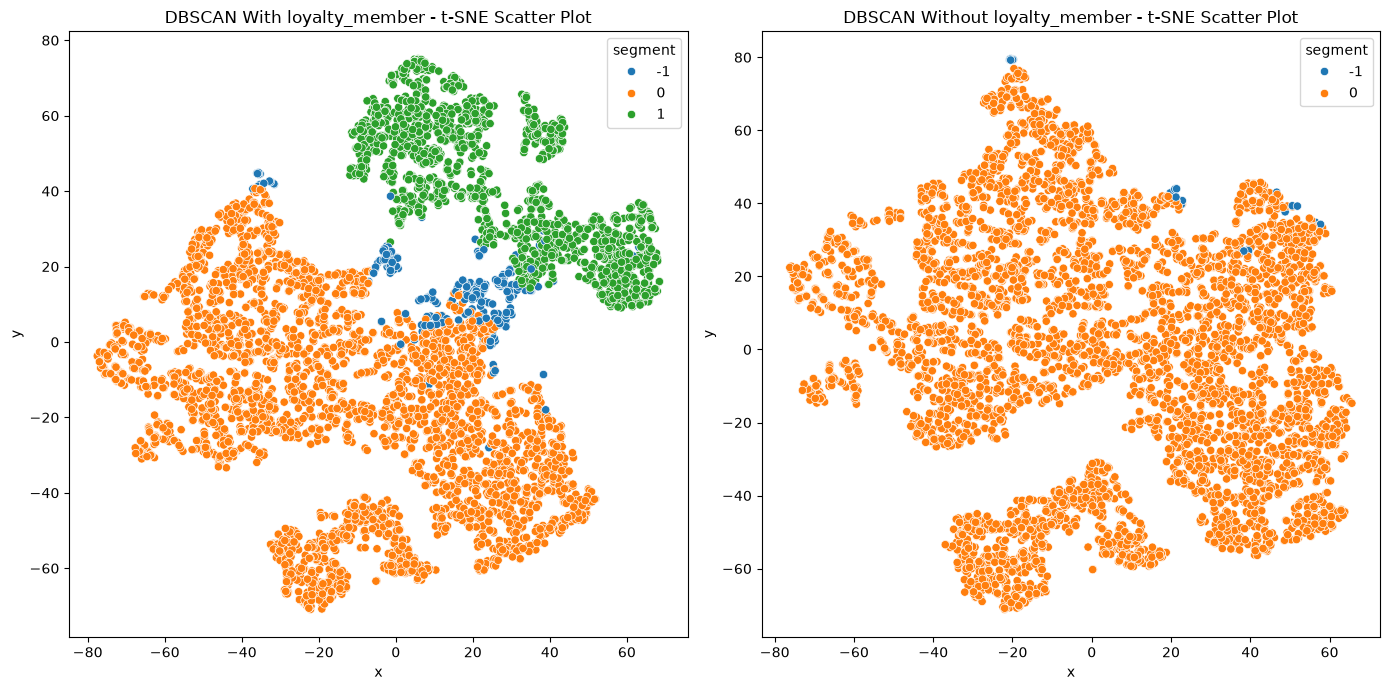

In [ ]:
# DBSCAN with loyalty_member (Using retail_scaled)
db_with_loyalty_member = DBSCAN (eps= 2.0, min_samples = min_samples)
db_with_loyalty_member_labels = db_with_loyalty_member.fit_predict(retail_scaled)

# DBSCAN without loyalty_member (Using binary_removed_scaled)
db_without_loyalty_member = DBSCAN (eps= 3.4, min_samples = min_samples_loyalty_dropped)
db_without_loyalty_member_labels = db_without_loyalty_member.fit_predict(binary_removed_scaled)

# Reuse t_SNE coordinates from k = 2 KMeans test: 
df_tsne_dbscan_with = pd.DataFrame({'x': tsne_data_k2[:, 0], 'y': tsne_data_k2[:, 1], 
                                   'segment': db_with_loyalty_member_labels})

# Reuse t-SNE coordinates from the k = 7 loyalty removed test: 
df_tsne_dbscan_without = pd.DataFrame({'x': tsne_data_k7[:, 0], 'y': tsne_data_k7[:, 1], 
                                   'segment': db_without_loyalty_member_labels})

# Create one figure of the side by side plots: 
fig, axes = plt.subplots(1, 2, figsize = (14, 7))

# Create the plots: 
sns.scatterplot(x = 'x', y = 'y', hue = 'segment', data = df_tsne_dbscan_with, palette = 'tab10', ax = axes[0])
axes[0].set_title('DBSCAN With loyalty_member - t-SNE Scatter Plot')
sns.scatterplot(x = 'x', y = 'y', hue = 'segment', data = df_tsne_dbscan_without, palette = 'tab10', ax = axes[1])
axes[1].set_title('DBSCAN Without loyalty_member - t-SNE Scatter Plot')

plt.tight_layout()
plt.show()

#### Plot Results: 

The t-SNE visulisations reinforce the points made previously. With loyalty_member included the model is able to identfy two clusters (Orange & Green) along side some noise points sitting in between. Then in the second plot with loyalty_member removed the seperation is removed and the points are gathered together into a single cluster along side some noise points located on the edge of the cluster. Together, the plots form visual confirmaiton that loyalty_member is the primary; and arguably the only; feature in both tests that contribute to the model identifying clusters. 

### Conclusion

The notebooks found wihtin this folder aimed to investigate and analyse the effectiveness machine learning alroithms possess in the context of segmenting consumers based on transaction data. There were two modesl used including Kmeans and DBSCAN both with varying inputs. 

**Key Findings**

> The KMeans algorithm was able to detect a quantifiable structure within both values of k (2 and 7). The DBSCAN model was less effective at identifying clusters and was only able to do it when the binary feature 'loyalty_member' remained in the dataset. Without the binary feature all points collapsed into one large cluster. 

**Review of Effectiveness**
To demonstrate the effectiveness of the segmentation achieved throughout the notebook, a single customer will be pulled from a cluster with a specific behavioural trait. This illustrates that the algorithms (more specifically the KMeans k = 7 algorithm) seen throughout the notebook are capable of producing actionable insights at the customer level:

In [ ]:
# Calculate the average customer profile from the cluster: 
avg_customer = retail_features.groupby('cluster_no_loyalty')[removed_feature_cols].mean()
# Print Label
print("HIGH CANCELLATION CLUSTER RESULTS")
# Print the specific cluster from the table:
avg_customer.loc[[3]]

High Cancellation cluster mean characteristics


,total_spend,atv,total_visits,total_item_count,cancellation_rate,unique_products,time_of_day,day_of_week,discount_rate
cluster_no_loyalty,,,,,,,,,
3,944.16943,191.763904,5.235234,555.832994,0.381494,47.02444,12.321792,2.285132,0.114185


In [ ]:
# Pull a customer from loyalty_member removed test:
# The cluster targeted s
example_customer = retail_features[retail_features['cluster_no_loyalty'] == 3].sample(1, random_state = 42)
# Print Label
print("CUSTOMER EXAMPLE FROM CLUSTER")
# Display the customer: 
example_customer[removed_feature_cols + ['customer_id', 'cluster_no_loyalty']]

CUSTOMER EXAMPLE FROM CLUSTER


,total_spend,atv,total_visits,total_item_count,cancellation_rate,unique_products,time_of_day,day_of_week,discount_rate,customer_id,cluster_no_loyalty
4610,292.34,146.17,2,112,0.5,16,8,1,0.055556,16956,3


The code blocks above display a specific cluster from the KMeans test completed without loyalty_member. More specifically, this cluster was characterised by its high cancellation rate. Below that is a single customer pulled at random from the same cluster. Aligning with the cluster, the customer has a high cancellation rate at 50% alongside other behaviours such as a low total spend (£292) and only 2 visits. 

The example above displays that the algorithms (specifically KMeans) has been able to recognise a pattern that would have likely gone unnoticed, but has become clearer once the customer is grouped with other customers sharing similar behavioural traits. This demonstrates a working example of unsupervised customer segmentation: revealing actionable behavioural segments within a customer dataset that would otherwise have been missed. 

To further the conclusion an example of an action that could be taken on this example specifically would be the ability for a business to target this cluster specifically, finding out what is causing the cancellation pattern within the segment. This could be done via a survey and could be completed for specific customers only, rather than a generic questionnaire sent out to the entire customer base. On the other hand, this specific customer (4610) could be given a discount or incentive for a product they routinely buy that can be redeemed on Tuesdays at 8am - given their customer profile indicates this is their preferred time to shop. 

To conclude, this example is evidence that the models deployed within this notebook were able to extract specific, characterisable customer segments with shared behaviours that enable further customer-base understanding and actionable insights. Supporting the conclusion that unsupervised machine learning algorithms are effective at segmenting consumers based on transaction data. 